In [1]:
library(data.table)
library(ggplot2)
library(dplyr)
library(LeyLabRMisc)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“replacing previous import ‘data.table::last’ by ‘tidytable::last’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘tidytable::first’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘tidytable::between’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::%notin%’ by ‘tidytable::%notin%’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::fread’ by ‘tidytable::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::fread’ by ‘data.table::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“rep

In [2]:
contacts <- fread("/tmp/global2/mbermejo/conda/hicexplorer/Micro-c/mock_combined_final/big_bins/contacts_final.tsv", sep = "\t")
contacts

seq1,seq2,value,category
<chr>,<chr>,<dbl>,<chr>
B_fragilis_pBF9343,B_fragilis_pBF9343,6940896.5,same_seq
P_nigrescens_p4,P_nigrescens_p4,6446211.2,same_seq
P_nigrescens_p3,P_nigrescens_p3,6381823.9,same_seq
B_fragilis,B_fragilis,6258674.2,same_seq
P_nigrescens_p2,P_nigrescens_p2,5398320.9,same_seq
S_flexneri_p1,S_flexneri_p1,5349880.3,same_seq
E_faecium_p1,E_faecium_p1,4990530.4,same_seq
P_nigrescens_chrom2,P_nigrescens_chrom2,4683258.9,same_seq
E_faecium,E_faecium,4501995.9,same_seq


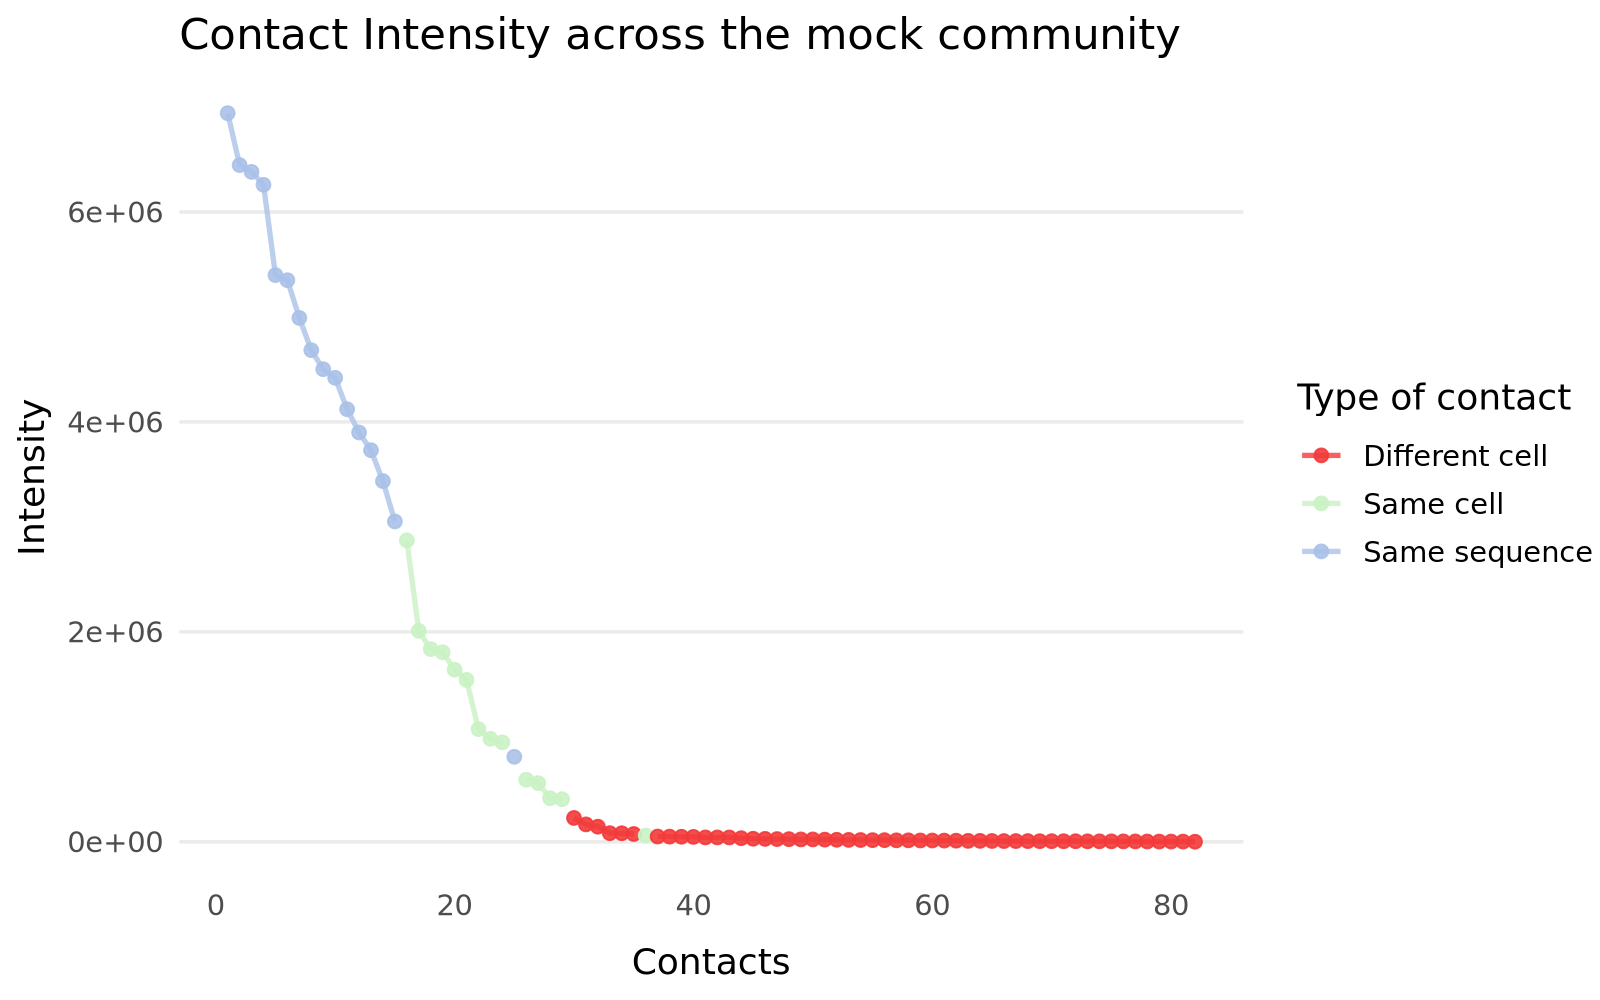

In [3]:
p.dims(8,5)
contacts %>%
  mutate(
    x = seq_along(value),
    grp = cumsum(category != lag(category, default = first(category)))
  ) %>%
  ggplot(aes(
    x = x,
    y = value,
    color = category,
    group = grp
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      same_seq  = "#aac1e7",
      same_cell = "#c9f1c4",
      different_cell  = "#f23a3a"
    ),
    labels = c(
      same_seq  = "Same sequence",
      same_cell = "Same cell",
      different_cell  = "Different cell"
    )
  ) +
  scale_y_continuous(
    labels = scales::label_scientific()
  ) +
  labs(
    title = "Contact Intensity across the mock community",
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    #legend.position = "top",
    #legend.direction = "horizontal",
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )